=== Kruskal's MST ===
Edge (0 - 3) Weight: 5
Edge (2 - 4) Weight: 5
Edge (3 - 5) Weight: 6
Edge (0 - 1) Weight: 7
Edge (1 - 4) Weight: 7
Edge (4 - 6) Weight: 9
Total MST Cost: 39

=== Prim's MST ===
Edge (0 - 3) Weight: 5
Edge (3 - 5) Weight: 6
Edge (0 - 1) Weight: 7
Edge (1 - 4) Weight: 7
Edge (4 - 2) Weight: 5
Edge (4 - 6) Weight: 9
Total MST Cost: 39


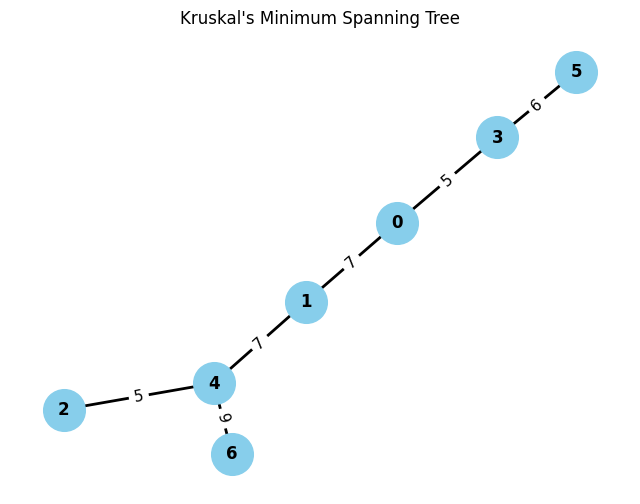

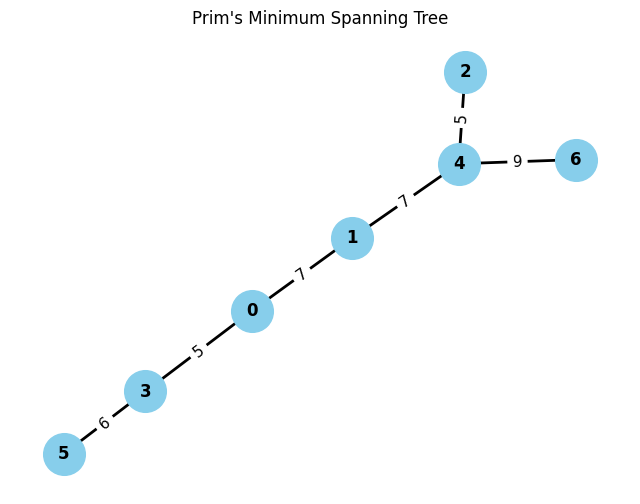

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# ---------- Union Find for Kruskal ----------
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, x, y):
        rx = self.find(x)
        ry = self.find(y)

        if rx == ry:
            return False

        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx

        self.parent[ry] = rx

        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1

        return True


# ---------- Kruskal ----------
def kruskal(n, edges):
    edges.sort()
    uf = UnionFind(n)

    mst = []
    cost = 0

    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v, w))
            cost += w

            if len(mst) == n - 1:
                break

    return mst, cost


# ---------- Prim ----------
def prim(n, adj, start=0):
    INF = float("inf")

    key = [INF] * n
    parent = [-1] * n
    inMST = [False] * n

    key[start] = 0
    pq = [(0, start)]

    mst = []
    cost = 0

    while pq:
        w, u = heapq.heappop(pq)

        if inMST[u]:
            continue

        inMST[u] = True

        if parent[u] != -1:
            mst.append((parent[u], u, w))
            cost += w

        for v, wt in adj.get(u, []):
            if not inMST[v] and wt < key[v]:
                key[v] = wt
                parent[v] = u
                heapq.heappush(pq, (wt, v))

    return mst, cost


# ---------- Draw MST ----------
def draw_mst(mst, title):
    G = nx.Graph()

    for u, v, w in mst:
        G.add_edge(u, v, weight=w)

    plt.figure(figsize=(8, 6))

    # Layout
    pos = nx.spring_layout(G, seed=42)

    # Draw graph
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color="skyblue",
        node_size=900
    )

    nx.draw_networkx_edges(
        G,
        pos,
        width=2
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=12,
        font_weight="bold"
    )

    # Draw weights
    labels = nx.get_edge_attributes(G, "weight")

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=labels,
        font_size=11
    )

    plt.title(title)
    plt.axis("off")
    plt.show()


# ---------- Graph ----------
n = 7

edges = [
    (7, 0, 1),
    (5, 0, 3),
    (8, 1, 2),
    (9, 1, 3),
    (7, 1, 4),
    (5, 2, 4),
    (15, 3, 4),
    (6, 3, 5),
    (8, 4, 5),
    (9, 4, 6),
    (11, 5, 6)
]

adj = {}

for w, u, v in edges:
    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, []).append((u, w))


# ---------- Run Algorithms ----------
k_mst, k_cost = kruskal(n, edges[:])
p_mst, p_cost = prim(n, adj)


# ---------- Kruskal Output ----------
print("=== Kruskal's MST ===")

for u, v, w in k_mst:
    print(f"Edge ({u} - {v}) Weight: {w}")

print("Total MST Cost:", k_cost)


# ---------- Prim Output ----------
print("\n=== Prim's MST ===")

for u, v, w in p_mst:
    print(f"Edge ({u} - {v}) Weight: {w}")

print("Total MST Cost:", p_cost)


# ---------- Graphical Representation ----------
draw_mst(k_mst, "Kruskal's Minimum Spanning Tree")

draw_mst(p_mst, "Prim's Minimum Spanning Tree")